Zertifikatstudium: GeoDataScience
gds050-01a: Ausgewählte Aspekte des Geoinformationswesens (S) (060884)
WiSe 25/26

Topic: Smart SH Emergency

Author: Justin Lingg-Laham
27.02.2026

# Basement — Preparation Notebook for 02_train_ug1 and 03_transfer_calibrate_ug2: Data Preprocessing and Patch Extraction 

This Notebook builds the training dataset for the U-Net-like model by extracting raster-based trining-patches (`X`, `y`) from pregenerated GeoTIFF layers. the input tensor `X` is composed of multiple raster channels (`DEM`, `Synthetic preciptation`, `Manning roughness coefficient`, `infiltration`), while the target `y` represents the `reference water depth` derived from the hydrodynamic simulation (SIMWE out of GRASS GIS-r.sim.water).

By configuring key hyperparameters (e.g. atch size, stride or samling methods), the notebook converts full-resolution rastrs into fixed-size `.npy` patches. These patches can then be loaded efficiently as a `tf.data.Dataset` for model training and subsequent notebooks.

Basement = Datenpipeline: GeoTiffs → Trainingspatches → TF-Dataset

The script used to generate the required GeoTIFF inputs is located in the Repository under:
data/hyd_mod_workflow_lingglaham

**Outputs**
- `patches/train/X_XXXXXX.npy`, `patches/train/y_XXXXXX.npy` (training patches)
- `patches/patch_index.csv` (index or metadata of extracted patches)
- `patches/reference_profile.json` (the georeferencing profile for later exports)

In [10]:
# Packages: used Packages and Bibliographies
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import rasterio
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from rasterio.warp import reproject, Resampling
from tqdm import tqdm

In [2]:

# 1.Konfiguration (Paths, Patch-Parameter, Filter, etc.)

## Paths and Folderstructure
BASE_DIR = os.getcwd() #current working dictory
INPUT_DIR = os.path.join(BASE_DIR, "input")     #build subfolder-paths:
SIMS_DIR  = os.path.join(BASE_DIR, "simulation")
PATCH_DIR = os.path.join(BASE_DIR, "patches")
TRAIN_PATCH_DIR = os.path.join(PATCH_DIR, "train") #Creation: Trainings-Patch-folder
os.makedirs(TRAIN_PATCH_DIR, exist_ok=True)

## Patch-Parameter
PATCH_SIZE = 64 #typical for CNN (Hofmann und Schüttrumpf 2021).
STRIDE = 32  # every 32 Pixel a new Patch (more examples = more context-overlap)

## Filter
WET_THR_M = 0.01          # from 1 cm, a pixel is considered "wet" (for Patch-Filter)
MIN_WET_FRAC = 0.001      # at least 0.1% wet pixel -> Patch considered "wet"
DRY_KEEP_PROB = 0.10      # only 10% complete /dry-Patches keep

## Infiltration (hydrologic modelling was constructed with constant infiltratio, due to error in GRASS GIS )
INFIL_CONST = 2.78e-6   

## file pattern (to find paths easier)
RAIN_GLOB  = "pos_synth_*_infil.tif"
DEPTH_GLOB = "synth_water_depth_*_pos*"

## Output-Metadata
INDEX_CSV = os.path.join(PATCH_DIR, "patch_index.csv")
PROFILE_JSON = os.path.join(PATCH_DIR, "reference_profile.json")

## Reproducibility: to ensure that the patch data record is generated identically each time it is run
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

In [3]:

# 2. IO-Helper functions for raster data (robust: float32, NoData to NaN, profiles)

## Function: read raster and metadata to give out NoData
def read_raster(path, as_float32=True, nodata_to_nan=True):
    with rasterio.open(path) as src:
        arr = src.read(1)
        profile = src.profile.copy()
        nodata = src.nodata

    if as_float32:
        arr = arr.astype("float32")

    if nodata_to_nan and nodata is not None and np.isfinite(nodata):
        arr = arr.astype("float32")
        arr[arr == np.float32(nodata)] = np.nan

    return arr, profile, nodata
    
## Function: Security Check to bring every raster into the same shape (size)
def assert_same_shape(*arrays, name="arrays"):
    shapes = [a.shape for a in arrays]
    if len(set(shapes)) != 1:
        raise ValueError(f"{name}: Shapes differ: {shapes}")

## Function: store 2D-Array as GeoTIFF  (with Georeference)
def save_geotiff(arr2d, profile, out_path, nodata=np.nan):
    out_profile = profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1)
    with rasterio.open(out_path, "w", **out_profile) as dst:
        out = arr2d.astype("float32")
        if np.isnan(nodata):
            dst.write(out, 1)
        else:
            out_profile.update(nodata=float(nodata))
            dst.write(out, 1)
## Function: Event-ID out of file names for correct allocation          
def extract_event_id(fp: str) -> str:
    base = os.path.basename(fp)
    m = re.search(r"(\d+_\d+)", base)
    if not m:
        raise ValueError(f"No event ID found in file name: {base}")
    return m.group(1)

In [4]:

# 3. Patch-Extraction for training-dataset

## file name-Patterns 
RAIN_GLOB_DEFAULT  = "pos_synth_*_infil.tif" # simulation/ug2/pos_synth_1_20_infil.tif
DEPTH_GLOB_DEFAULT = "synth_water_depth_*_pos*" # simulation/ug2/synth_water_depth_1_20_pos

## Function: Check wether a patch is NaN (broken) and is therefore skipped
def _has_invalid(patch: np.ndarray, nodata):
    """True wenn NaN oder nodata-Werte vorkommen."""
    if np.isnan(patch).any():
        return True
    if nodata is not None and np.isfinite(nodata):
        return np.any(patch == np.float32(nodata))
    return False

## Function: generate and store Patches, give them index
def extract_patches_and_save(
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    input_dir=INPUT_DIR,
    sims_dir=SIMS_DIR,
    train_patch_dir=TRAIN_PATCH_DIR,
    use_infil_raster=None, # we use constant infiltration. if we adjust it with raster, then change this term
    infil_const=INFIL_CONST,
    rain_glob=RAIN_GLOB_DEFAULT,
    depth_glob=DEPTH_GLOB_DEFAULT,
    wet_thr_m=WET_THR_M,
    min_wet_frac=MIN_WET_FRAC,
    dry_keep_prob=DRY_KEEP_PROB,
    index_csv=INDEX_CSV,
    profile_json=PROFILE_JSON,
    rng=rng,
):
    os.makedirs(train_patch_dir, exist_ok=True)

## core logic of this function::
    # load statistical raster (DEM, Mkoeff, Infil)
    dem_fp  = os.path.join(input_dir, "DEM.tif")
    mann_fp = os.path.join(input_dir, "mkoeff_UG.tif")

    dem, profile, dem_nod = read_raster(dem_fp)
    mann, _, mann_nod = read_raster(mann_fp)

    # constant Infiltration
    infil_arr = np.full(dem.shape, float(infil_const), dtype="float32")
    infil_nod = None
## bring all in the same shape
    assert_same_shape(dem, mann, infil_arr, name="Static rasters (DEM/Manning/Infil-const)")

    # find dynamic raster
    sim_rain_files  = sorted(glob.glob(os.path.join(sims_dir, rain_glob)))
    sim_depth_files = sorted(glob.glob(os.path.join(sims_dir, depth_glob)))

    if len(sim_rain_files) == 0:
        raise FileNotFoundError(f"No rain files found with: {os.path.join(sims_dir, rain_glob)}")
    if len(sim_depth_files) == 0:
        raise FileNotFoundError(f"No rain files found with: {os.path.join(sims_dir, depth_glob)}")

    ## Matching via event ID (prevents incorrect zip/sorting due to IDs that only occure in both)
    rain_map  = {extract_event_id(f): f for f in sim_rain_files}
    depth_map = {extract_event_id(f): f for f in sim_depth_files}
    common_ids = sorted(set(rain_map) & set(depth_map))

    missing_rain  = sorted(set(depth_map) - set(rain_map))
    missing_depth = sorted(set(rain_map) - set(depth_map))

    print("rain-files:", len(sim_rain_files), "Depth-files:", len(sim_depth_files))
    print("couples together:", len(common_ids))
    if missing_rain:
        print("Depth without rain (ID):", missing_rain[:10], "...")
    if missing_depth:
        print("Depth without rain (ID):", missing_depth[:10], "...")

    if len(common_ids) == 0:
        raise ValueError("No matching Rain/Depth pairs found. Check file names/ID extraction.")

    # Save the reference profile (transform/crs/height/width) to be able to output later predictions in a georeferenced format
    os.makedirs(os.path.dirname(profile_json), exist_ok=True)
    with open(profile_json, "w") as f:
        json.dump(
            {
                "transform": tuple(profile["transform"]),
                "crs": str(profile.get("crs")),
                "height": int(profile["height"]),
                "width": int(profile["width"]),
            },
            f,
            indent=2,
        )

    rows, cols = dem.shape

    ## Patch-Index + Filter + loop
    meta_rows = []
    cnt = 0

    for sid in tqdm(common_ids, total=len(common_ids), desc="Events"): #for every event (ID))
        ## load rain and depth
        rain_fp  = rain_map[sid] 
        depth_fp = depth_map[sid]

        rain, _, rain_nod = read_raster(rain_fp)
        depth, _, depth_nod = read_raster(depth_fp)

        ## Shapecheck against DEM (early error detection)
        if rain.shape != dem.shape or depth.shape != dem.shape:
            raise ValueError(
                f"Shape mismatch for Event {sid}: "
                f"DEM {dem.shape}, rain {rain.shape}, depth {depth.shape}. "
            )

         ## generate Sliding-Window over every patch
        for r0 in range(0, rows - patch_size + 1, stride):
            for c0 in range(0, cols - patch_size + 1, stride):
                patch_dem   = dem[r0:r0+patch_size, c0:c0+patch_size]
                patch_rain  = rain[r0:r0+patch_size, c0:c0+patch_size]
                patch_mann  = mann[r0:r0+patch_size, c0:c0+patch_size]
                patch_infil = infil_arr[r0:r0+patch_size, c0:c0+patch_size]
                patch_depth = depth[r0:r0+patch_size, c0:c0+patch_size]
                # Invalid?
                if (_has_invalid(patch_depth, depth_nod) or
                    _has_invalid(patch_dem,   dem_nod)   or
                    _has_invalid(patch_rain,  rain_nod)  or
                    _has_invalid(patch_mann,  mann_nod)  or
                    _has_invalid(patch_infil, infil_nod)):
                    continue

                ## Wet/Dry Filter & Balancing
                wet_frac = float(np.mean(patch_depth > wet_thr_m)) 
                is_wet = wet_frac >= min_wet_frac # Patch is wet 

                if (not is_wet) and (rng.random() > dry_keep_prob): #Patch is dry
                    continue
               ## store
                X = np.stack([patch_dem, patch_rain, patch_mann, patch_infil], axis=-1).astype("float32")
                y = patch_depth.astype("float32")

                np.save(os.path.join(train_patch_dir, f"X_{cnt:06d}.npy"), X)
                np.save(os.path.join(train_patch_dir, f"y_{cnt:06d}.npy"), y)
                # Metadata for every stored patch
                meta_rows.append(
                    {
                        "patch_id": f"{cnt:06d}",
                        "event_id": sid,
                        "row0": int(r0),
                        "col0": int(c0),
                        "wet_frac": wet_frac,
                        "max_depth_m": float(np.max(y)),
                        "mean_depth_m": float(np.mean(y)),
                        "rain_fp": os.path.basename(rain_fp),
                        "depth_fp": os.path.basename(depth_fp),
                    }
                )
                cnt += 1

    meta = pd.DataFrame(meta_rows)
    os.makedirs(os.path.dirname(index_csv), exist_ok=True)
    meta.to_csv(index_csv, index=False)

    print(f"Done. Saved Patches: {cnt}")
    print(f"Patch-Index: {index_csv}")
    print(f"Referenceprofile: {profile_json}")
    return meta

In [5]:

# 4. TensorFlow.data Dataset Loader 

## Function: estimates mean value and standart deviation per parameter (without calculating all patches pixel by pixel)
## max_files = how many patch files max are taken into account; pixels_per_file = how many pixels per file are sampled; seed = reproducible sampling
def compute_norm_params_from_files(patch_dir=TRAIN_PATCH_DIR, max_files=2000, pixels_per_file=4096, seed=42):
    rng = np.random.default_rng(seed)

    X_files = sorted(glob.glob(os.path.join(patch_dir, "X_*.npy")))[:max_files]
    y_files = sorted(glob.glob(os.path.join(patch_dir, "y_*.npy")))[:max_files]
    if len(X_files) == 0 or len(y_files) == 0:
        raise FileNotFoundError("no Patch-Files found (X_*.npy / y_*.npy).")
    if len(X_files) != len(y_files):
        raise ValueError(f"X/y mismatch: {len(X_files)} vs {len(y_files)}")

    sum_x = None
    sum_x2 = None
    n = 0
    y_max = 0.0

    for xf, yf in tqdm(list(zip(X_files, y_files)), desc="Norm stats"):
        X = np.load(xf).astype("float32")  # (H,W,C)
        y = np.load(yf).astype("float32")  # (H,W)
        y_max = max(y_max, float(np.max(y)))

        flat = X.reshape(-1, X.shape[-1])  # (H*W, C)
        if flat.shape[0] > pixels_per_file:
            idx = rng.choice(flat.shape[0], size=pixels_per_file, replace=False)
            samp = flat[idx]
        else:
            samp = flat

        if sum_x is None:
            sum_x = np.zeros(samp.shape[-1], dtype="float64")
            sum_x2 = np.zeros(samp.shape[-1], dtype="float64")

        sum_x += samp.sum(axis=0)
        sum_x2 += (samp**2).sum(axis=0)
        n += samp.shape[0]

    mean = (sum_x / max(n, 1)).astype("float32")
    var = (sum_x2 / max(n, 1) - mean.astype("float64")**2).astype("float32")
    std = np.sqrt(np.maximum(var, 1e-12)).astype("float32")
    return mean, std, float(y_max)

## Creates a high-performance tf.data.dataset with shapes (X,y)
def make_tf_dataset(
    patch_dir=TRAIN_PATCH_DIR,
    batch_size=8, # how many patches per Batch
    shuffle=True, # if they getting mixed
    seed=42,
    patch_size=None, # are also derived from X, therefore none
    channels=None,   # are also derived from X, therefore none
    means=None,
    stds=None,
    y_max=None,
):   ## read X_files and y_files lesen and check quantity
    X_files = sorted(glob.glob(os.path.join(patch_dir, "X_*.npy"))) 
    y_files = sorted(glob.glob(os.path.join(patch_dir, "y_*.npy")))
    if len(X_files) == 0 or len(y_files) == 0:
        raise FileNotFoundError("no Patch-Files found (X_*.npy / y_*.npy).")
    if len(X_files) != len(y_files):
        raise ValueError(f"X/y mismatch: {len(X_files)} vs {len(y_files)}")

    if patch_size is None or channels is None:
        X0 = np.load(X_files[0])
        if patch_size is None:
            patch_size = int(X0.shape[0])
        if channels is None:
            channels = int(X0.shape[-1])

    ds = tf.data.Dataset.from_tensor_slices((X_files, y_files))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X_files), 2000), seed=seed, reshuffle_each_iteration=True)

    y_max_f = None if y_max is None else float(y_max)

    def _load(xf, yf):
        def _np_load(a, b):
            X = np.load(a.decode("utf-8")).astype("float32")
            y = np.load(b.decode("utf-8")).astype("float32")[..., None]  # (H,W,1)

            if means is not None and stds is not None:
                X = (X - means) / np.maximum(stds, 1e-6)

            if y_max_f is not None and y_max_f > 0:
                y = y / y_max_f

            return X, y

        X, y = tf.numpy_function(_np_load, [xf, yf], [tf.float32, tf.float32])
        X.set_shape([patch_size, patch_size, channels])
        y.set_shape([patch_size, patch_size, 1])
        return X, y

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [6]:
# 5. Dataset-production
os.makedirs(TRAIN_PATCH_DIR, exist_ok=True) ##Output-folder-creation (if necessary)

meta = extract_patches_and_save(
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    input_dir=INPUT_DIR,
    sims_dir=SIMS_DIR,
    train_patch_dir=TRAIN_PATCH_DIR,
)
meta.head()

rain-files: 20 Depth-files: 20
couples together: 20


Events: 100%|██████████| 20/20 [00:23<00:00,  1.18s/it]


Done. Saved Patches: 26733
Patch-Index: /home/jupyter-lingglaham/projekt_hydro/patches/patch_index.csv
Referenceprofile: /home/jupyter-lingglaham/projekt_hydro/patches/reference_profile.json


,patch_id,event_id,row0,col0,wet_frac,max_depth_m,mean_depth_m,rain_fp,depth_fp
0,000000,1_20,32,32,0.140381,0.337305,0.011829,pos_synth_1_20_infil.tif,synth_water_depth_1_20_pos
1,000001,1_20,32,64,0.141846,0.372701,0.011777,pos_synth_1_20_infil.tif,synth_water_depth_1_20_pos
2,000002,1_20,32,96,0.144287,0.372701,0.010368,pos_synth_1_20_infil.tif,synth_water_depth_1_20_pos
3,000003,1_20,32,128,0.124268,0.429394,0.009077,pos_synth_1_20_infil.tif,synth_water_depth_1_20_pos
4,000004,1_20,32,160,0.138428,0.429394,0.010616,pos_synth_1_20_infil.tif,synth_water_depth_1_20_pos


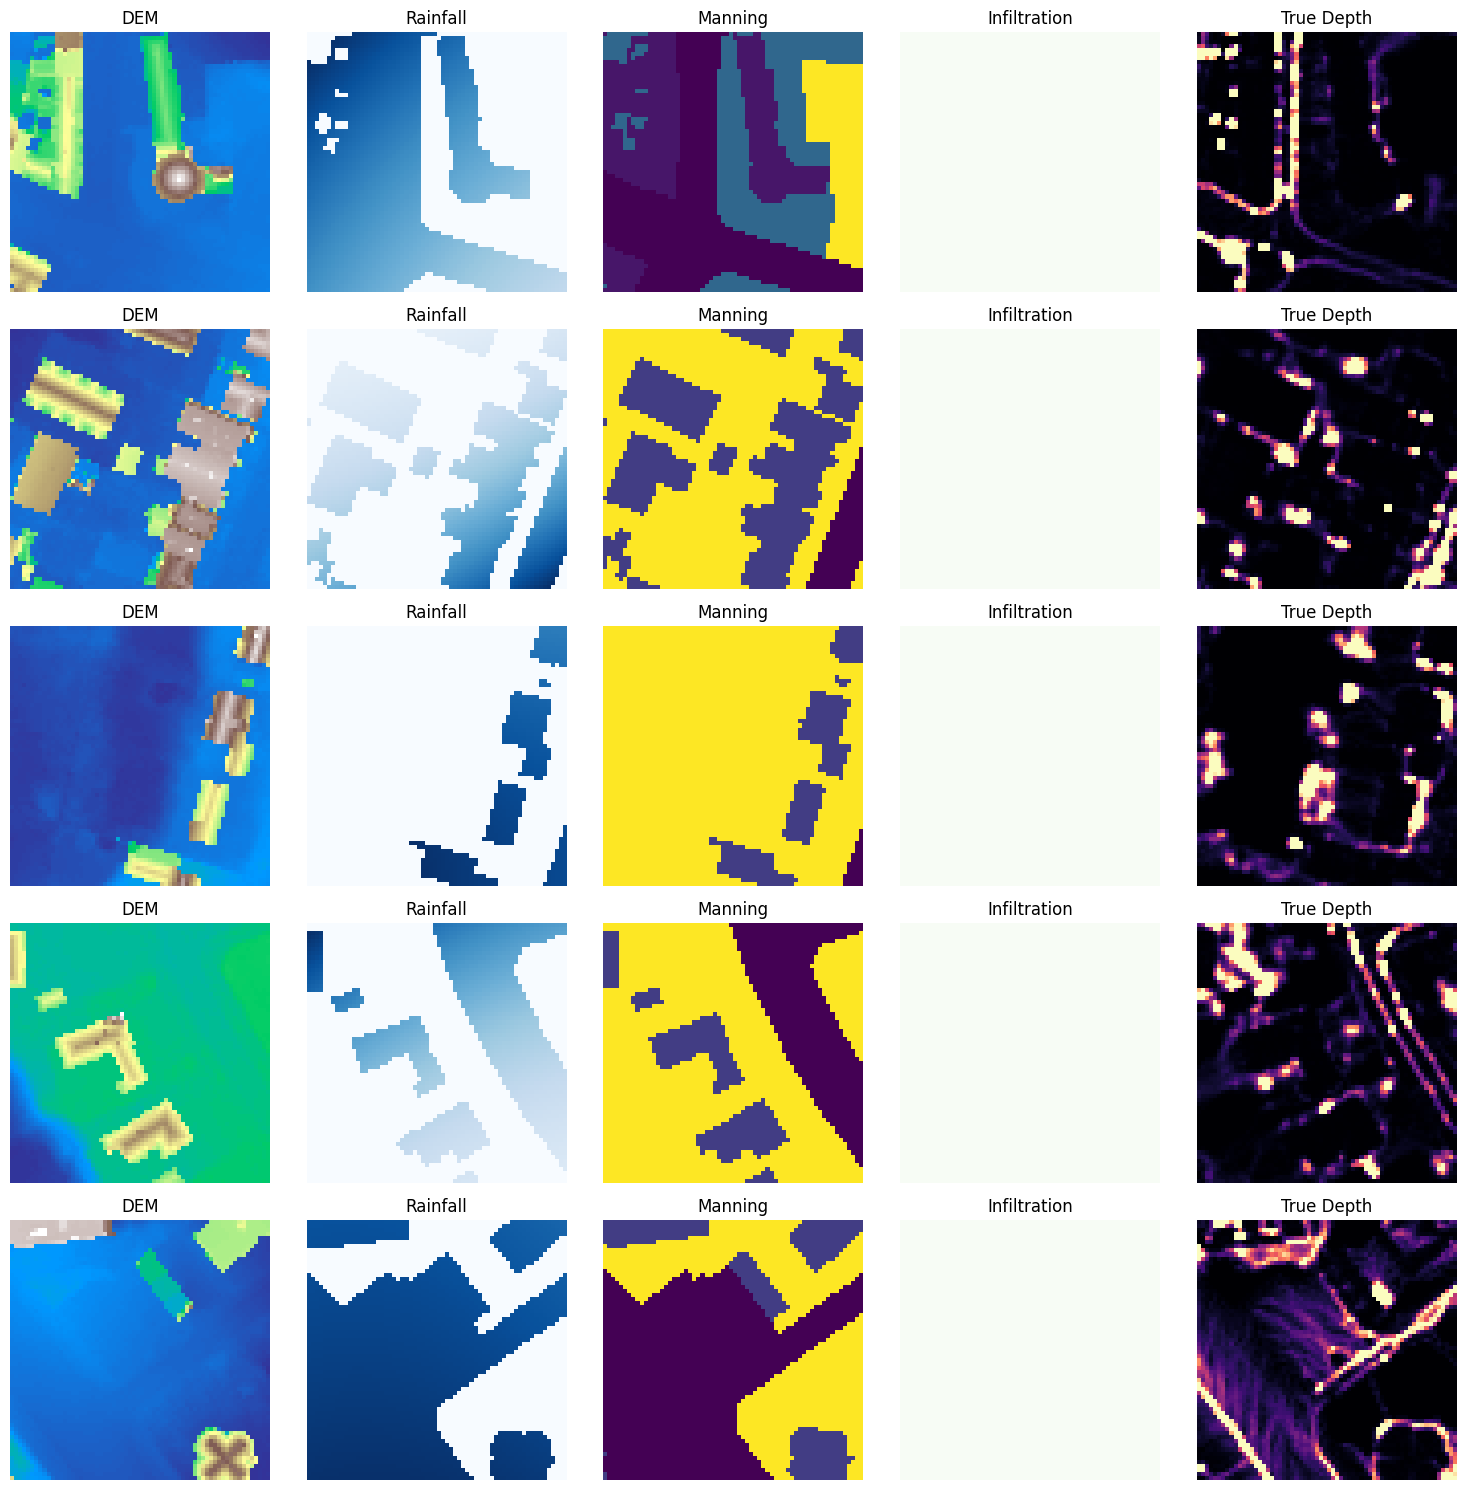

In [12]:
# 7. Verify that the data is error-free 
def show_random_patches(patch_dir="train_patches", n=5):
    X_files = sorted(glob.glob("patches/train/X_*.npy"))
    y_files = sorted(glob.glob("patches/train/y_*.npy"))

    idxs = random.sample(range(len(X_files)), n)

    fig, axs = plt.subplots(n, 5, figsize=(15, 3*n))

    for row, i in enumerate(idxs):
        X = np.load(X_files[i])
        y = np.load(y_files[i])

        # display individual channels
        axs[row,0].imshow(X[:,:,0], cmap="terrain")
        axs[row,0].set_title("DEM")

        axs[row,1].imshow(X[:,:,1], cmap="Blues")
        axs[row,1].set_title("Rainfall")

        axs[row,2].imshow(X[:,:,2], cmap="viridis")
        axs[row,2].set_title("Manning")

        axs[row,3].imshow(X[:,:,3], cmap="Greens")
        axs[row,3].set_title("Infiltration")

        axs[row,4].imshow(y, cmap="magma", vmin=0, vmax=np.percentile(y,95))
        axs[row,4].set_title("True Depth")

        for j in range(5):
            axs[row,j].axis("off")

    plt.tight_layout()
    plt.show()

# check
show_random_patches("train_patches", n=5)